In [1]:
import shutil
from pathlib import Path

baseline_dir = Path("titanic") / "baseline"

if baseline_dir.exists():
    shutil.rmtree(baseline_dir)

print("기존 baseline 폴더 삭제 완료")

기존 baseline 폴더 삭제 완료


# [LAB-04] 04. 베이스라인 구축

---

## 전처리 단계의 결론

| 구분 | 변수 | 처리 내용 | 비고 |
| :--- | :--- | :--- | :--- |
| **종속변수** | Survived | 0=사망, 1=생존 | 이진 분류 |
| **연속형** | Age | 변환 없음 | 단독 유의성은 낮으나 억제효과 가능성으로 투입 |
| **연속형** | Fare | log(1+x) 변환 | 왜도 4.37 → 0.55 |
| **연속형** | FamilySize | log(x) 변환 | 왜도 2.85 → 1.18 |
| **범주형** | Pclass | 라벨링 1=0, 2=1, 3=2 | 등급 순서대로 생존율 감소 |
| **범주형** | Embarked | 라벨링 C=0, Q=1, S=2 | Pclass 와 겹칠 가능성 |
| **범주형** | HasCabin | 라벨링 False=0, True=1 | Pclass 의 대리 지표 가능성 |
| **범주형** | Title | 라벨링 Master=0, Miss=1, Mr=2, Mrs=3, Officer=4 | 이 데이터 최고 연관 (V = 0.697) |

<br>

* **03단계에서 저장한 `titanic_features` 데이터셋(1306행 × 8열)을 그대로 사용한다.**
* **라벨링된 범주형 변수는 정수로 저장되어 있으므로, 불러온 뒤 `category` 타입으로 되돌려야 파이프라인이 더미 변수 인코딩 대상으로 인식한다.**
* **이번 단계의 목표: 분류 베이스라인 9종 학습·저장 → 성능 비교 → 최고 성능 모델 선정 → 모듈화 기능 (`cls_baseline`) 확인.**

# 01. 준비작업
---

In [2]:
from hossam import load_data
from helpers import *

import os             # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import glob as gl     # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈

# 훈련,검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 선형 계열 모델
from sklearn.linear_model import LogisticRegression, RidgeClassifier

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 트리계열 모델
from sklearn.tree import DecisionTreeClassifier

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.33


### 2. 데이터 불러오기 + 범주형 타입 변환
--- 

In [3]:
# 분석용 데이터 전처리가 완료된 데이터 셋 (03. 분석용 데이터 전처리 실습에서 저장한 결과)
origin = load_data("titanic_features")

# 라벨링된 범주형 변수는 정수로 저장되어 있으므로 category 타입으로 되돌린다.
# -> 파이프라인이 더미변수 인코딩 대상으로 인식한다. 종속변수 Survived 는 정수(0/1) 그대로 둔다.
df = my_qtcheck.set_type(origin, as_category=["Pclass", "Embarked", "HasCabin", "Title"])

📚 타이타닉호 침몰 데이터셋의 분석용 데이터 전처리 버전 (출처: 자체 작업)
<class 'pandas.DataFrame'>
RangeIndex: 1306 entries, 0 to 1305
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    1306 non-null   int64   
 1   Pclass      1306 non-null   category
 2   Age         1306 non-null   float64 
 3   Fare        1306 non-null   float64 
 4   Embarked    1306 non-null   category
 5   HasCabin    1306 non-null   category
 6   FamilySize  1306 non-null   float64 
 7   Title       1306 non-null   category
dtypes: category(4), float64(3), int64(1)
memory usage: 46.1 KB


### 3. 독립변수와 종속변수 분리후 훈련 . 검증 데이터 분할
--- 

In [4]:
# 독립변수 분리
feature = df.drop(columns=["Survived"])

# 종속변수 분리
target = df["Survived"]

# 훈련, 검증 데이터 분리
# 분류 문제이므로 stratify=target 을 지정해 훈련·검증 데이터의 생존 비율을 같게 맞춘다
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, 
                                                    random_state=RANDOM_STATE, stratify=target)


# 데이터 크기 확인
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1044, 7), (262, 7), (1044,), (262,))

### 4. 학습을 완료한 모델이 저장된 폴더
--- 

In [5]:
project_name = "titanic"
workdir = f"{project_name}/baseline"

if not os.path.exists(workdir):
    os.makedirs(workdir)

# 02. 선형 계열 모델

---

각 모델의 성능표(`my_ml.cls_score`)는 다음 7개 지표로 구성된다.

| 지표 | 의미 | 읽는 법 |
| --- | --- | --- |
| **Accuracy** | 전체 승객 중 생존 · 사망을 맞힌 비율 | 불균형 데이터에서는 다수 클래스만 맞혀도 높게 나와 |
| **Precision** | 생존으로 예측한 승객 중 실제 생존자 비율 | 오탐(FP) 억제 |
| **Recall** | 실제 생존자 중 생존으로 맞힌 비율 | 미탐(FN) 억제 |
| **F1** | Precision 과 Recall 의 조화평균 | 두 지표의 균형, 이번 실습의 주 지표 |
| **ROC_AUC** | 임계값을 바꿔가며 본 순위 매김 능력 | 0.5=무작위, 1=완벽 |
| **PR_AUC** | 양성(생존) 클래스 중심의 순위 매김 능력 | 불균형 데이터에서 ROC_AUC 의 보완 지표 |
| **DOR** | 진단오즈비 = (TP · TN) / (FP · FN) | 1=무작위, 클수록 좋음, 상한 없음 |

In [6]:
### 1. Logistic Regression

# 학습 모델 객체 생성
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "regression" 제거)
model_name = model.__class__.__name__.lower().removesuffix("regression")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=True,                                 # 스케일링 사용함 (규제가 계수 크기에 벌점을 매기므로 필수)
    drop_first=True,                            # 더미변수 생성(첫 컬럼 제거 -> 더미 트랩 방지)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력


대상: 1044행 x 7열 | 모델: logistic
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) -> 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: logistic
모델 저장: titanic/baseline/logistic.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
LogisticRegression,0.874,0.837,0.828,0.832,0.933,0.914,44.316


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'lo...ic'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': True, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [7]:
### 2. Ridge Classifier

# 학습 모델 객체 생성
# RidgeClassifier 는 확률(predict_proba)을 내지 못하지만, 결정함수의 마진으로 ROC_AUC·PR_AUC 가 계산된다
model = RidgeClassifier(random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=True,                                 # 스케일링 사용함
    drop_first=True,                            # 더미변수 생성(첫 컬럼 제거 -> 더미 트랩 방지)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: ridge
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) -> 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: ridge
모델 저장: titanic/baseline/ridge.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
RidgeClassifier,0.866,0.820,0.828,0.824,0.927,0.912,38.856


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'ridge'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': True, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


# 03. 비선형 계열 모델

---

In [8]:
### 1. KNN


# 학습 모델 객체 생성
model = KNeighborsClassifier(n_jobs=-1)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=True,                                 # 스케일링 사용함 (거리 기반 모델은 변수 단위 통일이 필수)
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: kneighbors
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) -> 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: kneighbors
모델 저장: titanic/baseline/kneighbors.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
KNeighborsClassifier,0.863,0.812,0.828,0.820,0.895,0.819,36.557


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'kn...rs'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [9]:
### 2. Support Vector Classifier

# 학습 모델 객체 생성
# probability=True 는 확률을 얻기 위해 내부에서 교차검증을 한 번 더 돌린다 (표본이 많으면 가장 느린 이유)
model = SVC(probability=True, random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환)
model_name = model.__class__.__name__.lower()

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=True,                                 # 스케일링 사용함 (마진 기반 모델은 변수 단위 통일이 필수)
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)

대상: 1044행 x 7열 | 모델: svc
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) -> 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=False)


C:\Users\itwill\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



모델 학습 완료: svc
모델 저장: titanic/baseline/svc.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
SVC,0.874,0.830,0.838,0.834,0.920,0.891,44.551


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'svc'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [10]:
### 3. Decision Tree

# 학습 모델 객체 생성
model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=False,                                # 스케일링 사용 안함 (분기 기준이 대소 관계뿐)
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: decisiontree
모델 저장: titanic/baseline/decisiontree.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
DecisionTreeClassifier,0.794,0.718,0.747,0.733,0.787,0.637,13.677


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'de...ee'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


# 04.앙상블 모델

--- 

In [11]:
### 1. Random Forest

# 학습 모델 객체 생성
model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=False,                                # 스케일링 사용 안함
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모

대상: 1044행 x 7열 | 모델: randomforest
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: randomforest
모델 저장: titanic/baseline/randomforest.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
RandomForestClassifier,0.836,0.780,0.788,0.784,0.909,0.876,23.805


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'ra...st'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [12]:
### 2. XGBoost

# 학습 모델 객체 생성
# XGBoost 는 종속변수가 0부터 시작하는 연속된 정수여야 한다 (Survived 는 0/1 이므로 그대로 사용 가능)
model = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=False,                                # 스케일링 사용 안함
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: xgb
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: xgb
모델 저장: titanic/baseline/xgb.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
XGBClassifier,0.847,0.798,0.798,0.798,0.915,0.893,28.242


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'xgb'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [13]:
### 3. LightGBM

# 학습 모델 객체 생성
model = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=False,                                # 스케일링 사용 안함
    encode=True,                                # 더미변수 생성(첫 컬럼 제거 안함)
    save_path=f"{workdir}/{model_name}.pkl"     # 모델 저장 경로
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: lgbm
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: lgbm
모델 저장: titanic/baseline/lgbm.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
LGBMClassifier,0.889,0.850,0.859,0.854,0.936,0.916,59.905


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'lgbm'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': True, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


In [14]:
### 4. CatBoost

# 학습 모델 객체 생성
model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)

# 모델이름 문자열 구성 (모델 객체의 클래스 이름을 소문자 변환 후 "classifier" 제거)
model_name = model.__class__.__name__.lower().removesuffix("classifier")

# 파이프라인 구축 -> 학습 -> 저장
model = my_ml.fit_pipeline(
    model=model,                                # 학습 모델
    x_train=x_train, y_train=y_train,           # 훈련 데이터 (독립,종속)
    vif=True,                                   # 다중공선성 확인 여부
    scale=False,                                # 스케일링 사용 안함
    encode=False,  # CatBoost는 자체적으로 범주형 처리하므로 encode=False
    save_path=f"{workdir}/{model_name}.pkl",   # 모델 저장 경로
    # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
    model__cat_features=my_qtcheck.get_categorical_column_names(x_train)
)

display(my_ml.cls_score(model, x_test, y_test))  # 모델 성능평가
display(model)                                  # 모델 구조 출력

대상: 1044행 x 7열 | 모델: catboost
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: (변환 없음)

모델 학습 완료: catboost
모델 저장: titanic/baseline/catboost.pkl


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
Model,,,,,,,
CatBoostClassifier,0.889,0.857,0.848,0.853,0.927,0.909,59.600


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Age','Fare',...,'HasCabin','FamilySize','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
name_,str,'ca...st'
pipeline_info_,dict,"{'ca...te': 'mo...nt', 'co...ls': ['Age', 'Fare', 'Fa...ze'], 'dr...st': False, 'encode': False, ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"


# 05.최고 성능 모델 선정

--- 

In [15]:
### 1. 학습 모델 파일 목록

# 작업폴더 내의 모든 pkl 파일 목록 확인
model_pickles = gl.glob(f"{workdir}/*.pkl")
print(model_pickles)

['titanic/baseline\\catboost.pkl', 'titanic/baseline\\decisiontree.pkl', 'titanic/baseline\\kneighbors.pkl', 'titanic/baseline\\lgbm.pkl', 'titanic/baseline\\logistic.pkl', 'titanic/baseline\\randomforest.pkl', 'titanic/baseline\\ridge.pkl', 'titanic/baseline\\svc.pkl', 'titanic/baseline\\xgb.pkl']


In [16]:
print(RANDOM_STATE)

3217


In [17]:
### 2. 학습 모델 불러오기

models = {}                                 # 모델명과 모델 객체를 저장할 딕셔너리

for p in model_pickles:
    model_name = p.split(".")[0]            # 파일 목록에서 파일명만 분리
    model = my_ml.load_model(p)             # 모델 로드
    models[model_name] = model              # 모델명과 모델 객체를 딕셔너리에 저장

# 로드된 모델과 모델 객체의 타입 출력
for name, model in models.items():
    print(f"- {name}: {type(model)}")

- titanic/baseline\catboost: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\decisiontree: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\kneighbors: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\lgbm: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\logistic: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\randomforest: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\ridge: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\svc: <class 'sklearn.pipeline.Pipeline'>
- titanic/baseline\xgb: <class 'sklearn.pipeline.Pipeline'>


In [18]:
### 3. 모델간 성능평가 비교

score_table = my_ml.cls_compare_models(
    models,
    x_test,
    y_test,
    primary="F1",
    aux=["ROC_AUC", "Accuracy"]
)

# 화면 표시용 index만 간단히 정리
score_table.index = (
    score_table.index.astype(str)
    .str.replace("\\", "/", regex=False)
    .str.split("/")
    .str[-1]
)

score_table


◆ Score Table Ranking : primary='F1', aux=['ROC_AUC', 'Accuracy']

▲ step1: 주 지표(F1) 기준 정렬 - 높을수록 좋음 (DESC)
     1. titanic/baseline\lgbm F1      =        0.854
     2. titanic/baseline\catboost F1      =        0.853
     3. titanic/baseline\svc F1      =        0.834
     4. titanic/baseline\logistic F1      =        0.832
     5. titanic/baseline\ridge F1      =        0.824
     6. titanic/baseline\kneighbors F1      =        0.820
     7. titanic/baseline\xgb F1      =        0.798
     8. titanic/baseline\randomforest F1      =        0.784
     9. titanic/baseline\decisiontree F1      =        0.733

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
    - 1등 F1      : 0.854
    - 허용 범위      : F1 >= 0.812
    - 근소 격차 그룹 (6) : ['titanic/baseline\\lgbm', 'titanic/baseline\\catboost', 'titanic/baseline\\svc', 'titanic/baseline\\logistic', 'titanic/baseline\\ridge', 'titanic/baseline\\kneighbors']
    - 그룹 외부      (3) : ['titanic/baseline\\xgb', 'titanic/baseline\\randomforest', 'titanic/baseline\\d

,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR,F1_Gap
name,,,,,,,,,,,
lgbm,1,Contender,LGBMClassifier,0.889,0.850,0.859,0.854,0.936,0.916,59.905,0.000
catboost,2,Contender,CatBoostClassifier,0.889,0.857,0.848,0.853,0.927,0.909,59.600,0.001
svc,3,Contender,SVC,0.874,0.830,0.838,0.834,0.920,0.891,44.551,0.020
logistic,4,Contender,LogisticRegression,0.874,0.837,0.828,0.832,0.933,0.914,44.316,0.022
ridge,5,Contender,RidgeClassifier,0.866,0.820,0.828,0.824,0.927,0.912,38.856,0.030
kneighbors,6,Contender,KNeighborsClassifier,0.863,0.812,0.828,0.820,0.895,0.819,36.557,0.034
xgb,7,Outside,XGBClassifier,0.847,0.798,0.798,0.798,0.915,0.893,28.242,0.056
randomforest,8,Outside,RandomForestClassifier,0.836,0.780,0.788,0.784,0.909,0.876,23.805,0.070
decisiontree,9,Outside,DecisionTreeClassifier,0.794,0.718,0.747,0.733,0.787,0.637,13.677,0.122


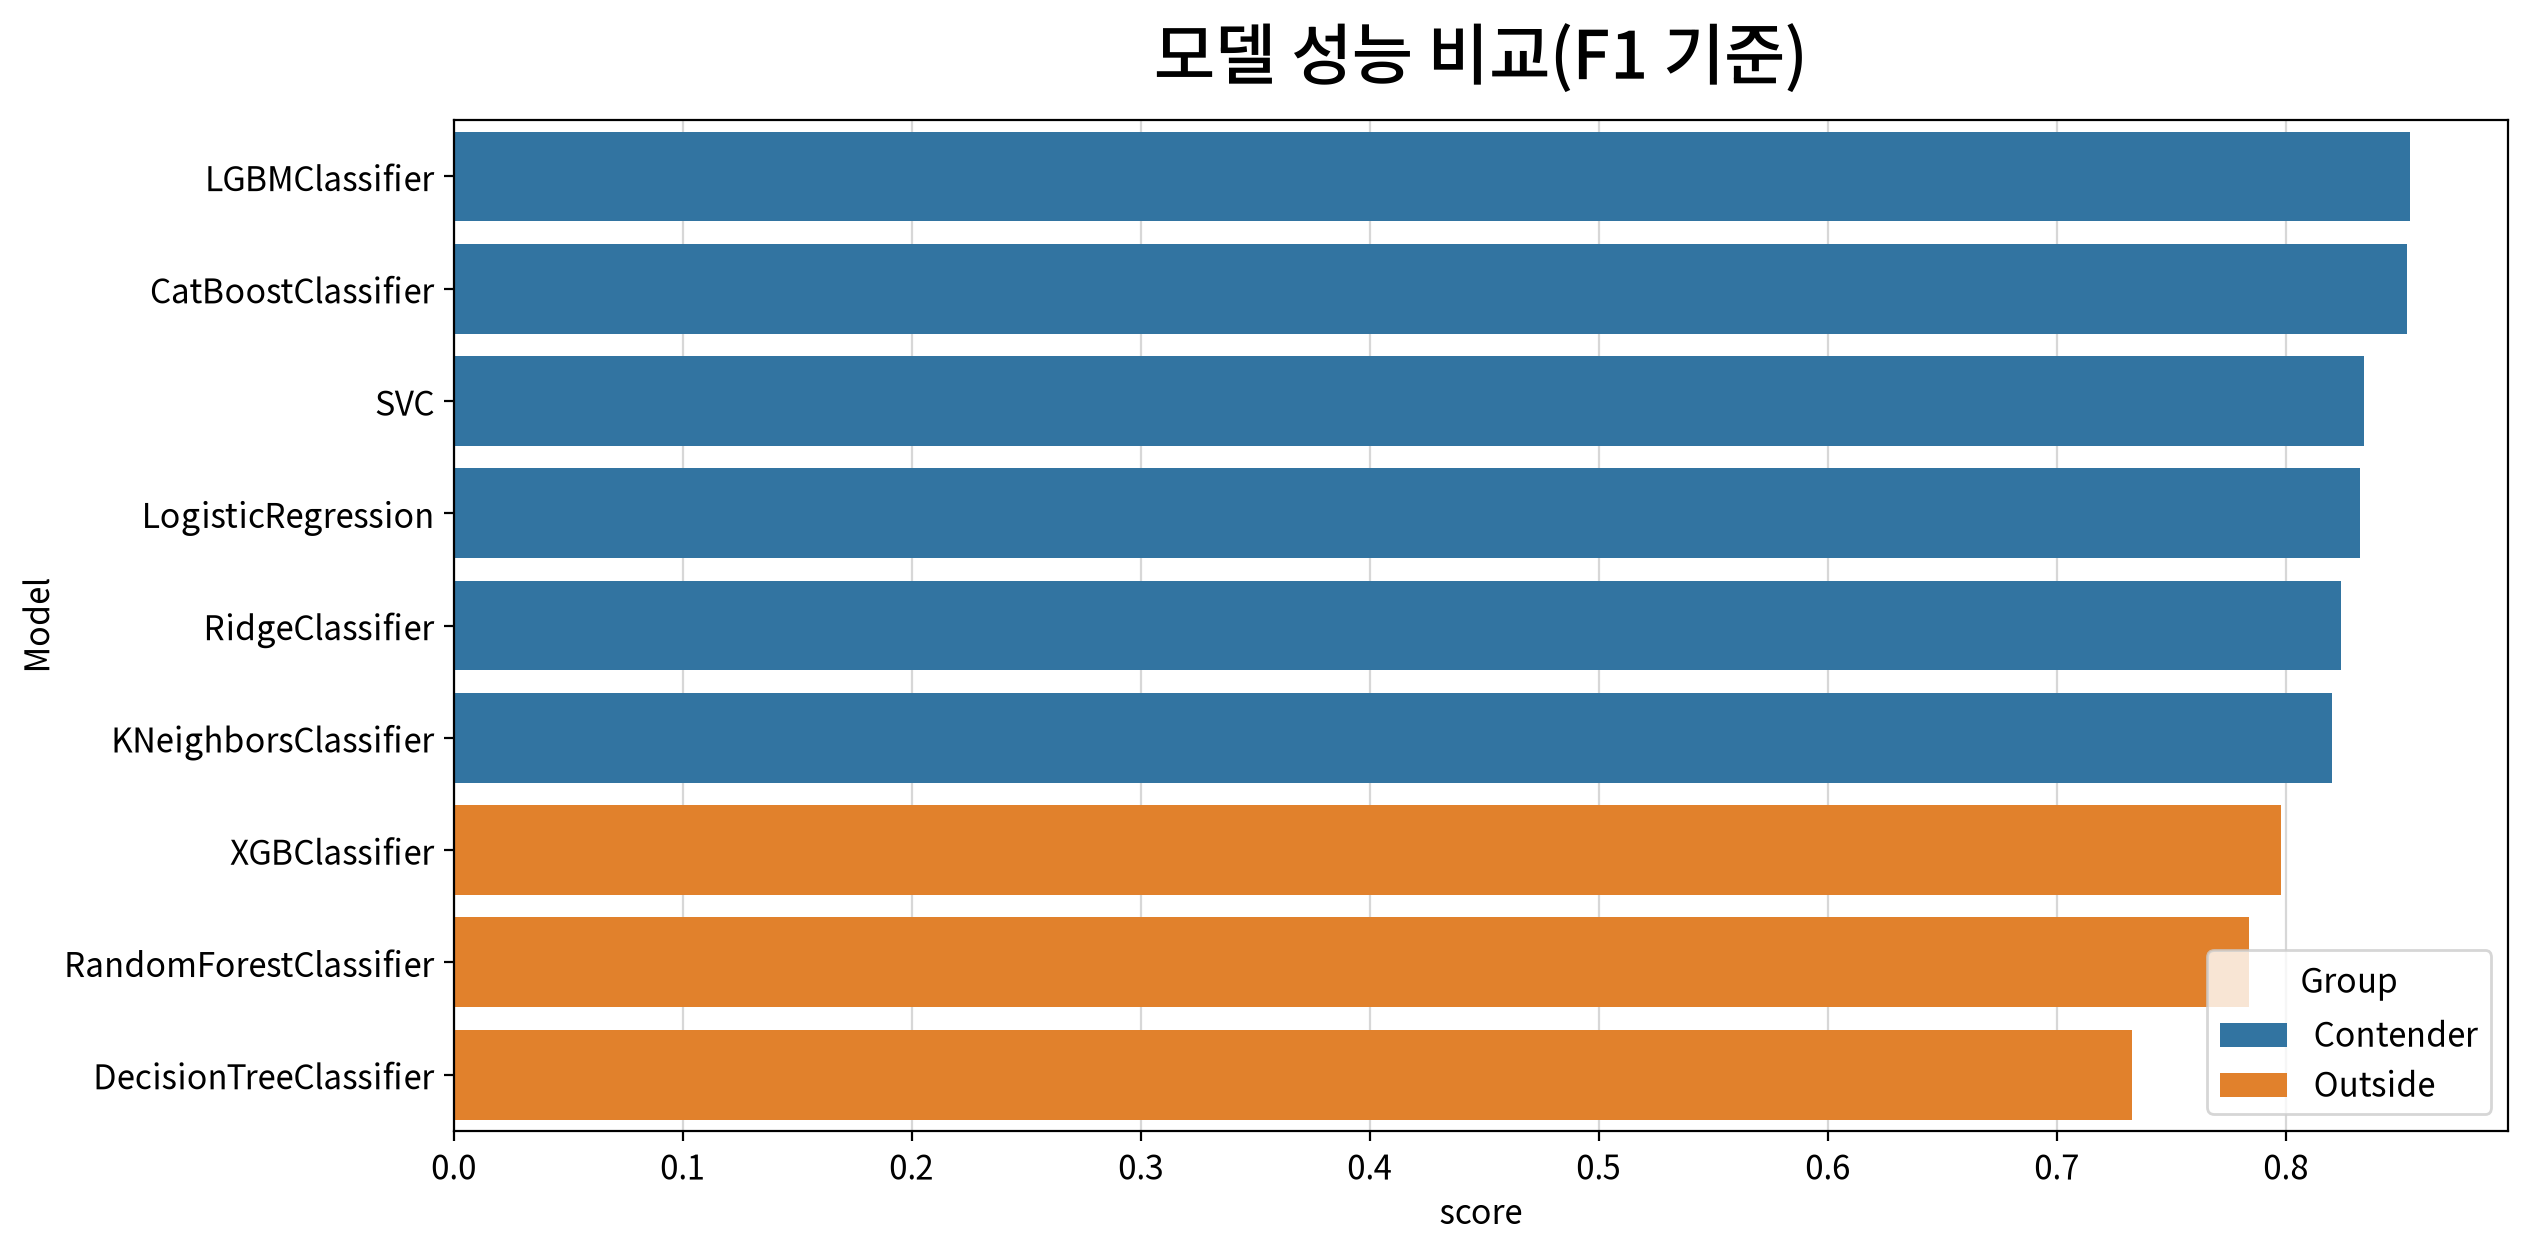

<Axes: title={'center': '모델 성능 비교(F1 기준)'}, xlabel='score', ylabel='Model'>

In [19]:
### 4. 주 지표 기준 성능비교 시각화

# 분류 지표는 모두 높을수록 좋으므로 F1 값을 그대로 점수로 사용한다 (회귀의 RMSE 처럼 역수를 취하지 않는다)

score_table["score"] = score_table["F1"]

my_plot.barplot(
    score_table,
    y="Model",
    x="score",
    hue="Group",
    palette="tab10",
    title="모델 성능 비교(F1 기준)"
)

# 06.모듈화 기능 확인

--- 

In [20]:
# 06. 모듈화 기능 확인  

작업 폴더: titanic\baseline
학습 완료 [1/9] : logistic
학습 완료 [2/9] : ridge
학습 완료 [3/9] : kneighbors
학습 완료 [4/9] : svc


C:\Users\itwill\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


학습 완료 [5/9] : decisiontree
학습 완료 [6/9] : randomforest
학습 완료 [7/9] : xgb
학습 완료 [8/9] : lgbm
학습 완료 [9/9] : catboost


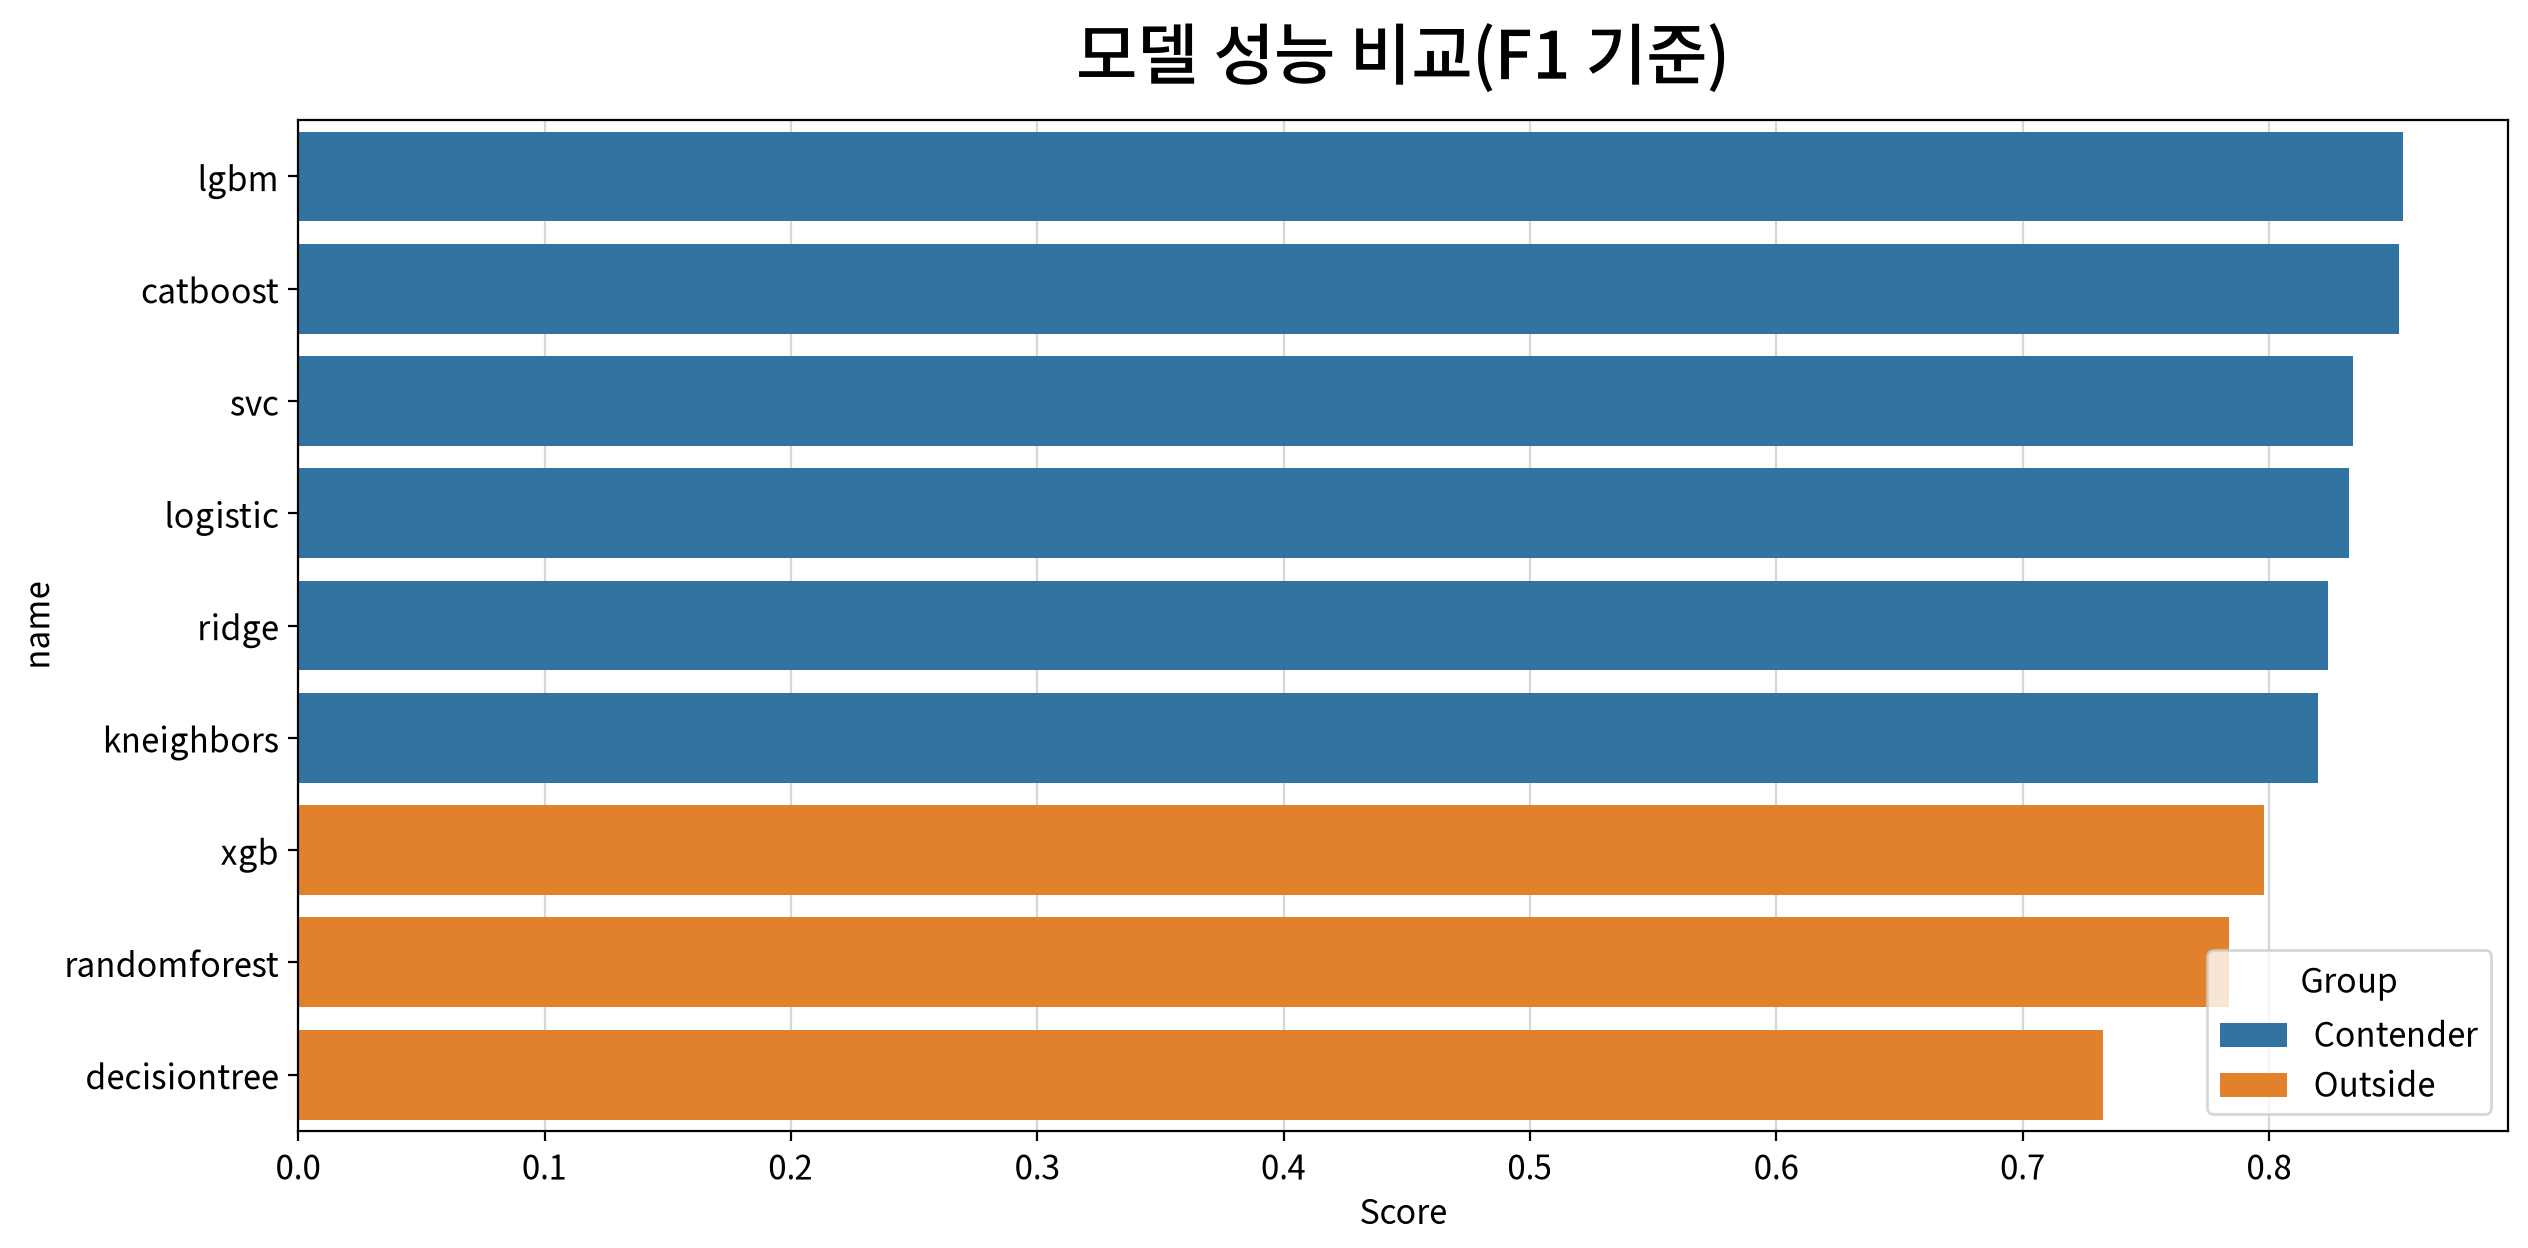


모델 9개 학습·저장 완료 → titanic\baseline


,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR,F1_Gap,Score
name,,,,,,,,,,,,
lgbm,1,Contender,LGBMClassifier,0.889,0.850,0.859,0.854,0.936,0.916,59.905,0.000,0.854
catboost,2,Contender,CatBoostClassifier,0.889,0.857,0.848,0.853,0.927,0.909,59.600,0.001,0.853
svc,3,Contender,SVC,0.874,0.830,0.838,0.834,0.920,0.891,44.551,0.020,0.834
logistic,4,Contender,LogisticRegression,0.874,0.837,0.828,0.832,0.933,0.914,44.316,0.022,0.832
ridge,5,Contender,RidgeClassifier,0.866,0.820,0.828,0.824,0.927,0.912,38.856,0.030,0.824
kneighbors,6,Contender,KNeighborsClassifier,0.863,0.812,0.828,0.820,0.895,0.819,36.557,0.034,0.820
xgb,7,Outside,XGBClassifier,0.847,0.798,0.798,0.798,0.915,0.893,28.242,0.056,0.798
randomforest,8,Outside,RandomForestClassifier,0.836,0.780,0.788,0.784,0.909,0.876,23.805,0.070,0.784
decisiontree,9,Outside,DecisionTreeClassifier,0.794,0.718,0.747,0.733,0.787,0.637,13.677,0.122,0.733


CPU times: total: 22.5 s
Wall time: 17.3 s


In [47]:
%%time
my_ml.cls_baseline("titanic", x_train, y_train, x_test, y_test);

작업 폴더: titanic\baseline
학습 완료 [1/9] : logistic
학습 완료 [2/9] : ridge
학습 완료 [3/9] : kneighbors


C:\Users\itwill\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


학습 완료 [4/9] : svc
학습 완료 [5/9] : decisiontree
학습 완료 [6/9] : randomforest
학습 완료 [7/9] : xgb
학습 완료 [8/9] : lgbm
학습 완료 [9/9] : catboost


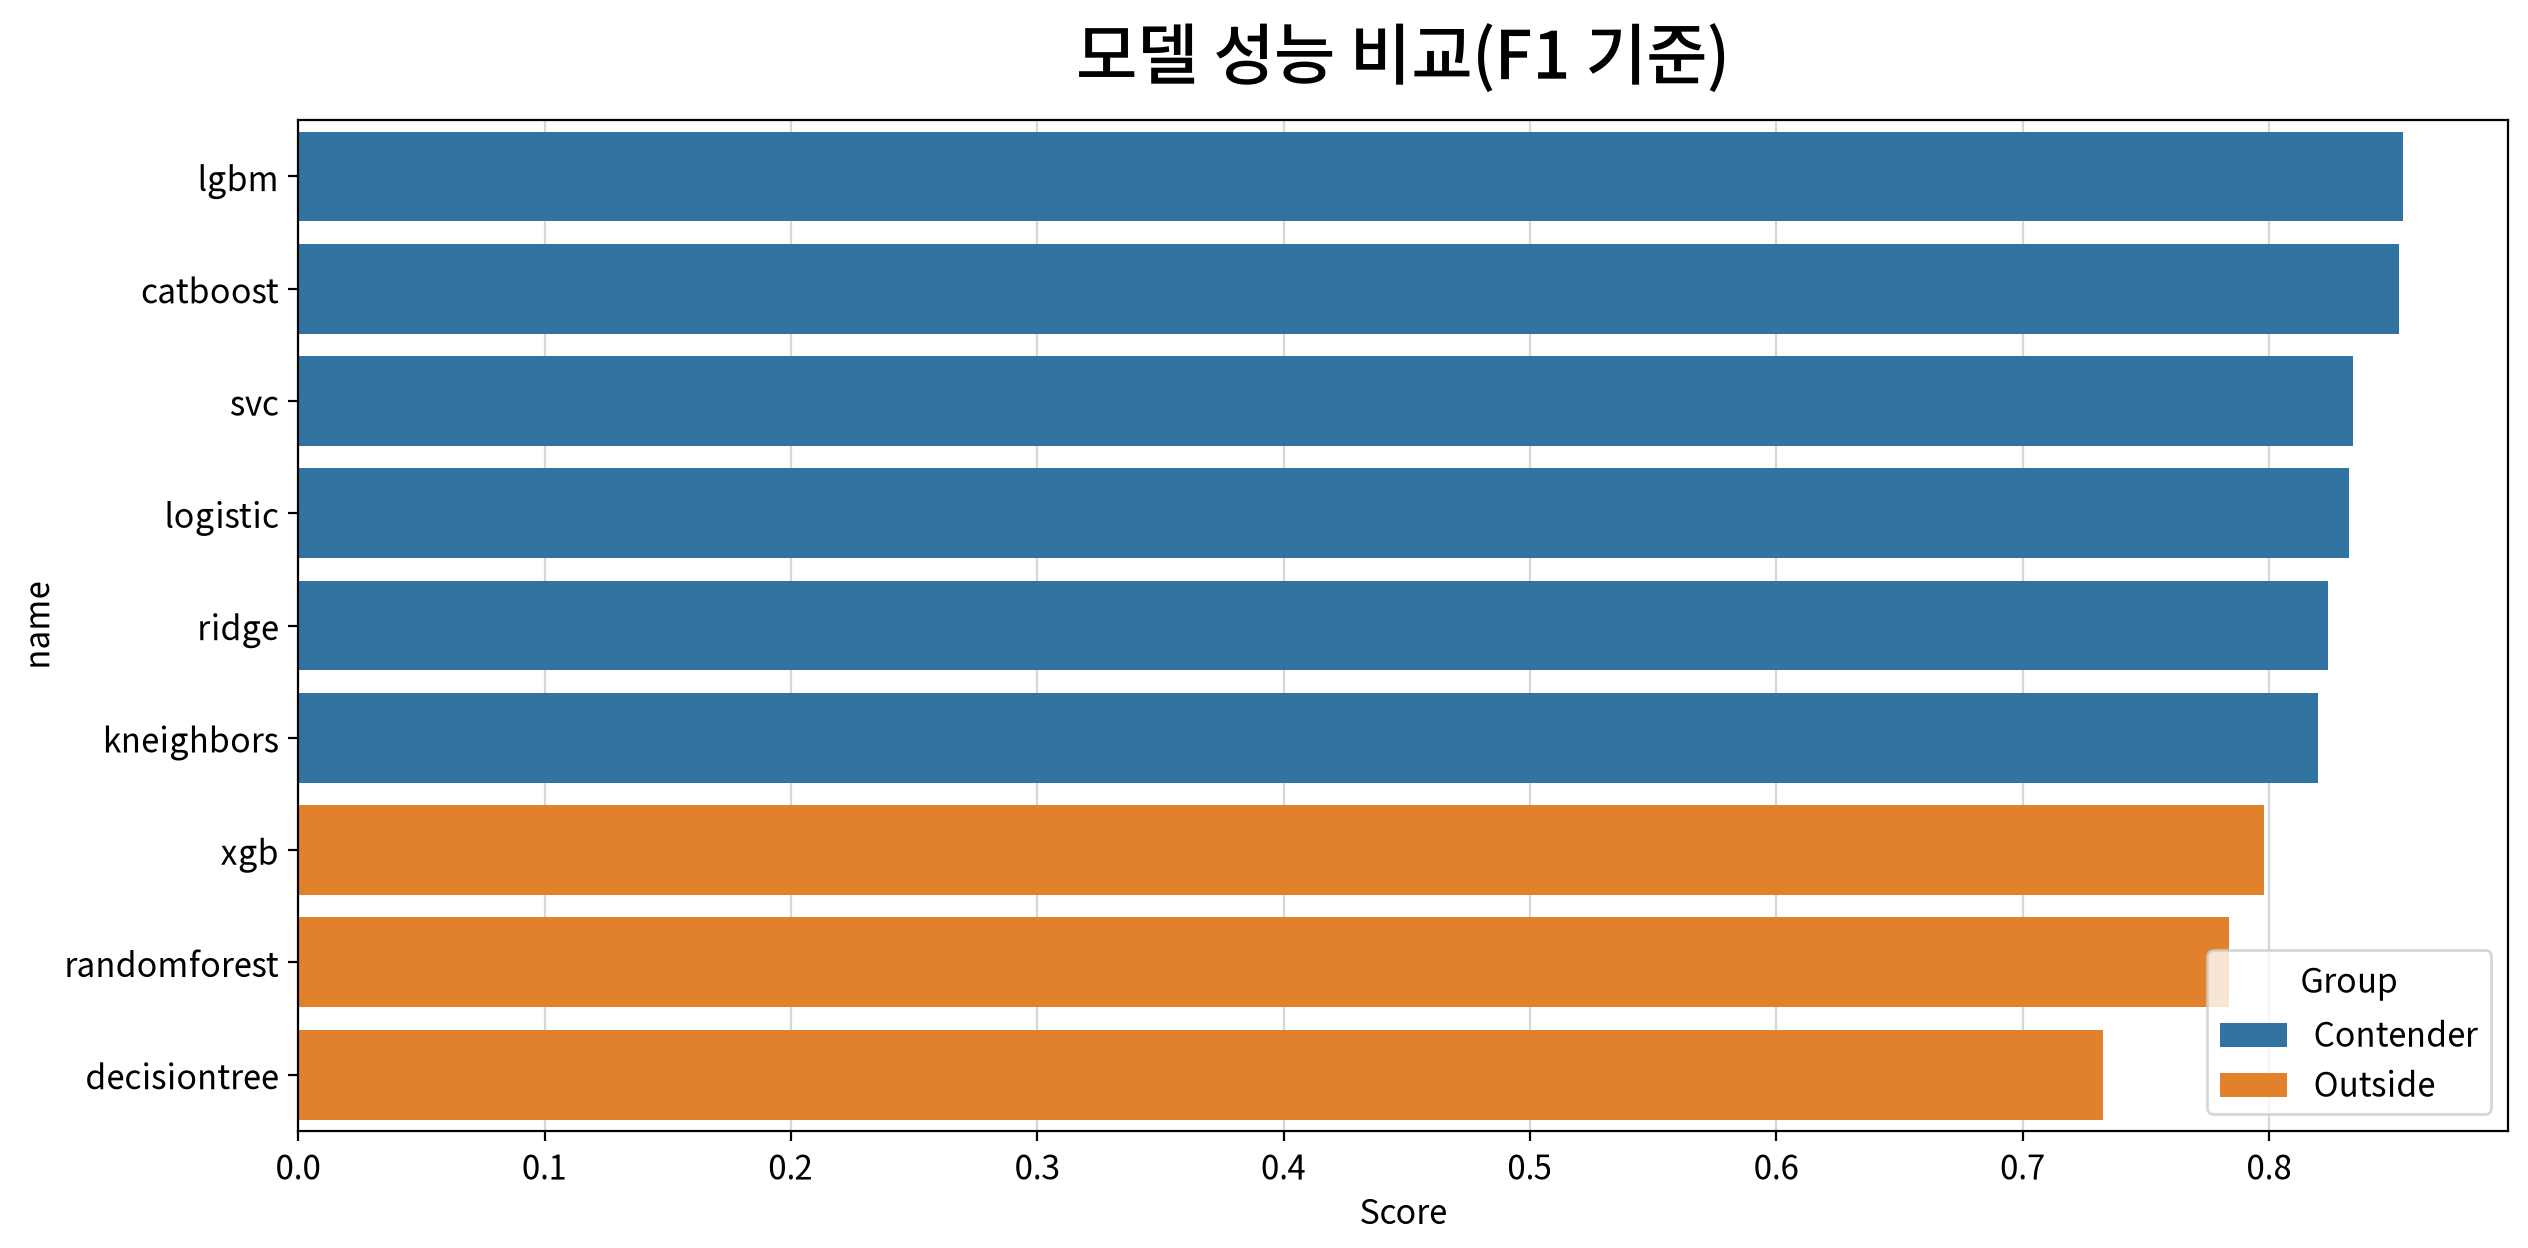


모델 9개 학습·저장 완료 → titanic\baseline


,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR,F1_Gap,Score
name,,,,,,,,,,,,
lgbm,1,Contender,LGBMClassifier,0.889,0.850,0.859,0.854,0.936,0.916,59.905,0.000,0.854
catboost,2,Contender,CatBoostClassifier,0.889,0.857,0.848,0.853,0.927,0.909,59.600,0.001,0.853
svc,3,Contender,SVC,0.874,0.830,0.838,0.834,0.920,0.891,44.551,0.020,0.834
logistic,4,Contender,LogisticRegression,0.874,0.837,0.828,0.832,0.933,0.914,44.316,0.022,0.832
ridge,5,Contender,RidgeClassifier,0.866,0.820,0.828,0.824,0.927,0.912,38.856,0.030,0.824
kneighbors,6,Contender,KNeighborsClassifier,0.863,0.812,0.828,0.820,0.895,0.819,36.557,0.034,0.820
xgb,7,Outside,XGBClassifier,0.847,0.798,0.798,0.798,0.915,0.893,28.242,0.056,0.798
randomforest,8,Outside,RandomForestClassifier,0.836,0.780,0.788,0.784,0.909,0.876,23.805,0.070,0.784
decisiontree,9,Outside,DecisionTreeClassifier,0.794,0.718,0.747,0.733,0.787,0.637,13.677,0.122,0.733


CPU times: total: 19.1 s
Wall time: 35.5 s


In [46]:
%%time
df_result = my_ml.cls_baseline("titanic", x_train, y_train, x_test, y_test)

In [44]:
from itertools import product

results = []

# vif × scale × encode × drop_first
for vif, scale, encode, drop_first in product([False, True], repeat=4):
    
    try:
        model = my_ml.fit_pipeline(
            model=DecisionTreeClassifier(
                random_state=RANDOM_STATE
            ),
            x_train=x_train,
            y_train=y_train,
            vif=vif,
            scale=scale,
            encode=encode,
            drop_first=drop_first
        )

        score = my_ml.cls_score(
            model,
            x_test,
            y_test,
            pos_label=1
        )

        results.append({
            "vif": vif,
            "scale": scale,
            "encode": encode,
            "drop_first": drop_first,
            "Accuracy": score.iloc[0]["Accuracy"],
            "F1": score.iloc[0]["F1"],
        })

    except Exception as e:
        results.append({
            "vif": vif,
            "scale": scale,
            "encode": encode,
            "drop_first": drop_first,
            "Accuracy": None,
            "F1": None,
            "Error": str(e)
        })

pd.DataFrame(results)

대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: (변환 없음)
  명목형: (변환 없음)

모델 학습 완료: decisiontree
대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: (변환 없음)
  명목형: (변환 없음)

모델 학습 완료: decisiontree
대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: (변환 없음)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: decisiontree
대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: (변환 없음)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: decisiontree
대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형: ['Age', 'Fare', 'FamilySize']

전처리 단계
  연속형: 정규화(standard)
  명목형: (변환 없음)

모델 학습 완료: decisiontree
대상: 1044행 x 7열 | 모델: decisiontree
명목형: ['Pclass', 'Embark

,vif,scale,encode,drop_first,Accuracy,F1
0,False,False,False,False,0.802,0.745
1,False,False,False,True,0.802,0.745
2,False,False,True,False,0.794,0.733
3,False,False,True,True,0.794,0.735
4,False,True,False,False,0.802,0.745
5,False,True,False,True,0.802,0.745
6,False,True,True,False,0.794,0.733
7,False,True,True,True,0.794,0.735
8,True,False,False,False,0.802,0.745
9,True,False,False,True,0.802,0.745


In [43]:
from itertools import product
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

results = []

# 2 × 2 × 2 × 2 = 16개 조합
for vif, scale, encode, drop_first in product(
    [False, True],
    [False, True],
    [False, True],
    [False, True]
):

    try:
        model = my_ml.fit_pipeline(
            model=RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            x_train=x_train,
            y_train=y_train,
            vif=vif,
            scale=scale,
            encode=encode,
            drop_first=drop_first,
            verbose=False
        )

        score = my_ml.cls_score(
            model,
            x_test,
            y_test,
            pos_label=1
        )

        results.append({
            "vif": vif,
            "scale": scale,
            "encode": encode,
            "drop_first": drop_first,
            "Accuracy": score.iloc[0]["Accuracy"],
            "Precision": score.iloc[0]["Precision"],
            "Recall": score.iloc[0]["Recall"],
            "F1": score.iloc[0]["F1"],
            "ROC_AUC": score.iloc[0]["ROC_AUC"],
            "PR_AUC": score.iloc[0]["PR_AUC"],
            "DOR": score.iloc[0]["DOR"],
        })

    except Exception as e:
        results.append({
            "vif": vif,
            "scale": scale,
            "encode": encode,
            "drop_first": drop_first,
            "Error": str(e)
        })


rf_compare = pd.DataFrame(results)

display(rf_compare)

,vif,scale,encode,drop_first,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,DOR
0,False,False,False,False,0.821,0.745,0.798,0.771,0.903,0.849,19.896
1,False,False,False,True,0.821,0.745,0.798,0.771,0.903,0.849,19.896
2,False,False,True,False,0.836,0.780,0.788,0.784,0.909,0.876,23.805
3,False,False,True,True,0.832,0.772,0.788,0.780,0.914,0.889,22.609
4,False,True,False,False,0.821,0.745,0.798,0.771,0.904,0.850,19.896
5,False,True,False,True,0.821,0.745,0.798,0.771,0.904,0.850,19.896
6,False,True,True,False,0.836,0.780,0.788,0.784,0.909,0.876,23.805
7,False,True,True,True,0.832,0.772,0.788,0.780,0.914,0.889,22.609
8,True,False,False,False,0.821,0.745,0.798,0.771,0.903,0.849,19.896
9,True,False,False,True,0.821,0.745,0.798,0.771,0.903,0.849,19.896
